In [ ]:
#importing the dependacies
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn.datasets
from sklearn.preprocessing  import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

In [ ]:
import json
import pandas as pd

def load_and_combine_datasets(legit_path, phishing_path):
    # Load legitimate URLs
    with open(legit_path, 'r') as f:
        legitimate_urls = json.load(f)

    # Load phishing URLs
    with open(phishing_path, 'r') as f:
        phishing_urls = json.load(f)

    # Create DataFrames with labels
    df_legit = pd.DataFrame({'url': legitimate_urls, 'label': 'legitimate'})
    df_phish = pd.DataFrame({'url': phishing_urls, 'label': 'phishing'})

    # Combine the datasets
    df_combined = pd.concat([df_legit, df_phish], ignore_index=True)

    # Shuffle the combined dataset
    df_combined = df_combined.sample(frac=1).reset_index(drop=True)

    return df_combined

# Set file paths
legit_path = '/content/data_legitimate_36400.json'
phishing_path = '/content/data_phishing_37175.json'

# Get combined dataset
df = load_and_combine_datasets(legit_path, phishing_path)

# Print some rows to check
print("df (first 10 rows):")
print(df.head(10))  # change the number as needed

# Optional: save to CSV
df.to_csv('phising_url_dataset.csv', index=False)


df (first 10 rows):
                                                 url       label
0  http://www.bestbuy.com/site/routers/wireless-r...  legitimate
1  http://www.rooferexpert.com/css/8933617-dosar-...    phishing
2  http://www.performanceoutdooradvertising.com/a...    phishing
3  https://www.androiddrawer.com/24611/download-e...  legitimate
4  https://shippingandfreightresource.com/port-an...  legitimate
5  https://www.quora.com/How-do-you-delete-messag...  legitimate
6  https://www.theguardian.com/media-network/seri...  legitimate
7  http://cooperativamagisteriodepichincha.fin.ec...    phishing
8  http://www.animationcareerreview.com/articles/...  legitimate
9                http://www.selfhelpenterprises.org/  legitimate


In [ ]:
#printing the datset
print(df)

                                                     url       label
0      http://www.bestbuy.com/site/routers/wireless-r...  legitimate
1      http://www.rooferexpert.com/css/8933617-dosar-...    phishing
2      http://www.performanceoutdooradvertising.com/a...    phishing
3      https://www.androiddrawer.com/24611/download-e...  legitimate
4      https://shippingandfreightresource.com/port-an...  legitimate
...                                                  ...         ...
73570  http://radiocatolicalaconsentida.com/funciones...    phishing
73571  http://www.utlitydiscountplans.com/sixes/loads...    phishing
73572                                  http://crcqc.com/  legitimate
73573   http://auditcg.ge/irs/home/?617564697463672e6765    phishing
73574         http://lobaare.tk/durella/newy/fledin.html    phishing

[73575 rows x 2 columns]


In [ ]:
#printing first 5 rows of dataset
df.head()

,url,label
0,http://www.bestbuy.com/site/routers/wireless-r...,legitimate
1,http://www.rooferexpert.com/css/8933617-dosar-...,phishing
2,http://www.performanceoutdooradvertising.com/a...,phishing
3,https://www.androiddrawer.com/24611/download-e...,legitimate
4,https://shippingandfreightresource.com/port-an...,legitimate


In [ ]:
#data analysis
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 73575 entries, 0 to 73574
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   url     73575 non-null  object
 1   label   73575 non-null  object
dtypes: object(2)
memory usage: 1.1+ MB


In [ ]:
df.shape

(73575, 2)

In [ ]:
df.isnull().sum()

,0
url,0
label,0


In [ ]:
#finding count of different type
df['label'].value_counts()

,count
label,
phishing,37175
legitimate,36400


<Axes: xlabel='label'>

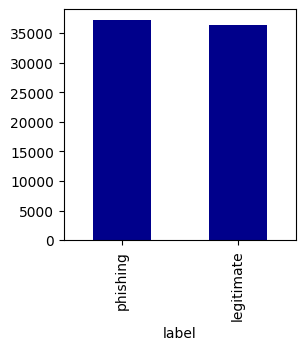

In [ ]:
#bar plot for different types of url
df['label'].value_counts().plot(kind='bar',color='darkblue',figsize=(3,3))


In [ ]:
#text preprocessing
#using wordcloud of nlp to find the distribution in above two cases to gt most of the tokens distribution in different types of url
from wordcloud import WordCloud

In [ ]:
#divivding the dataset into two different classes to draw there wordcloud individually
phising=df[df.label=='phishing']
legitimate=df[df.label=='legitimate']

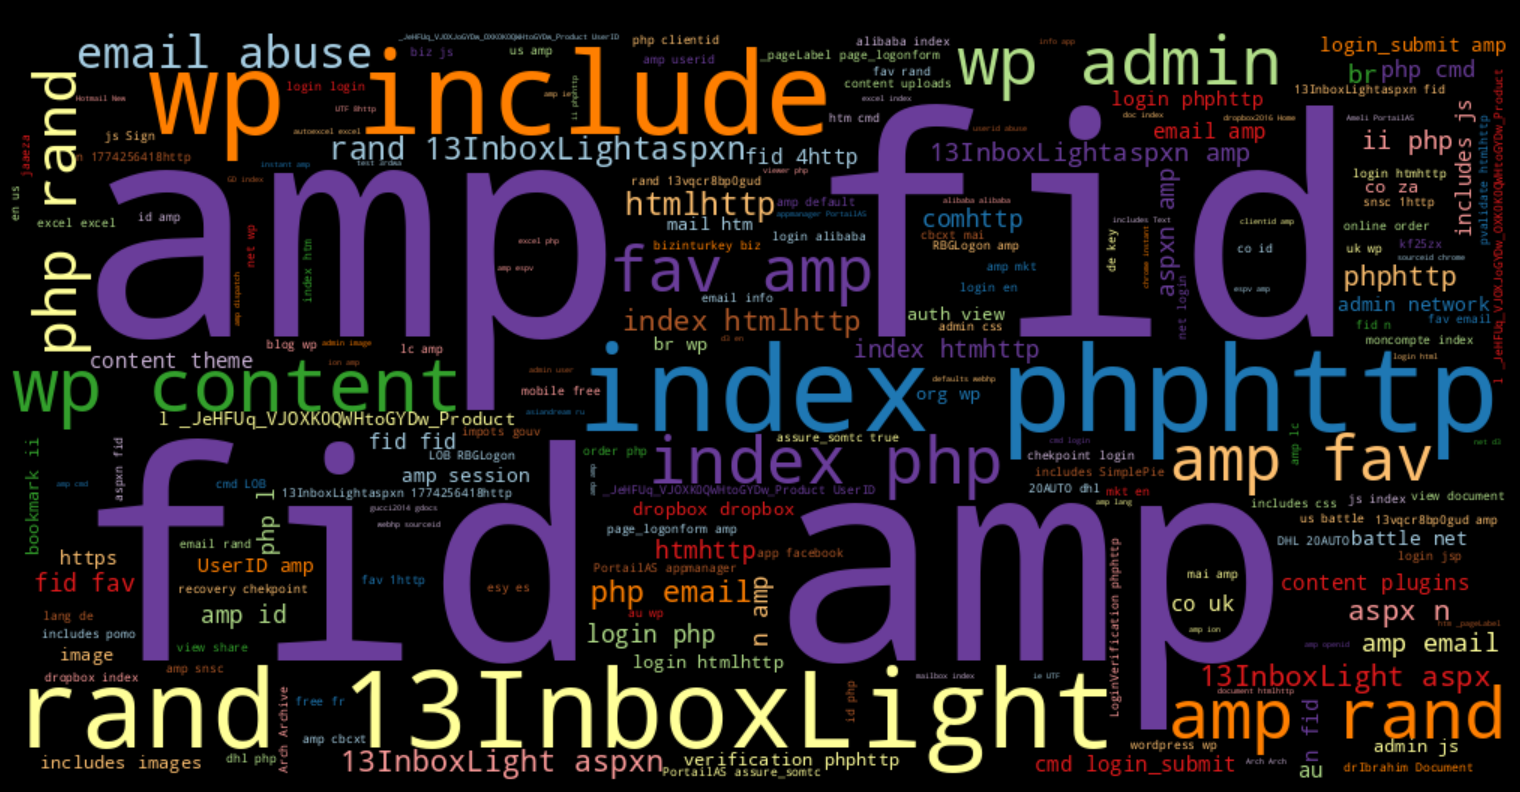

In [ ]:
#wordcloud for phising url
phising_url=''.join(list(phising.url.values))
wordcloud=WordCloud(width=1000,height=500,colormap='Paired').generate(phising_url)
plt.figure(figsize=(15,15),facecolor='k')
plt.imshow(wordcloud,interpolation='bilinear')
plt.axis('off')
plt.title('Phishing URL')
plt.tight_layout(pad=0)
plt.show()

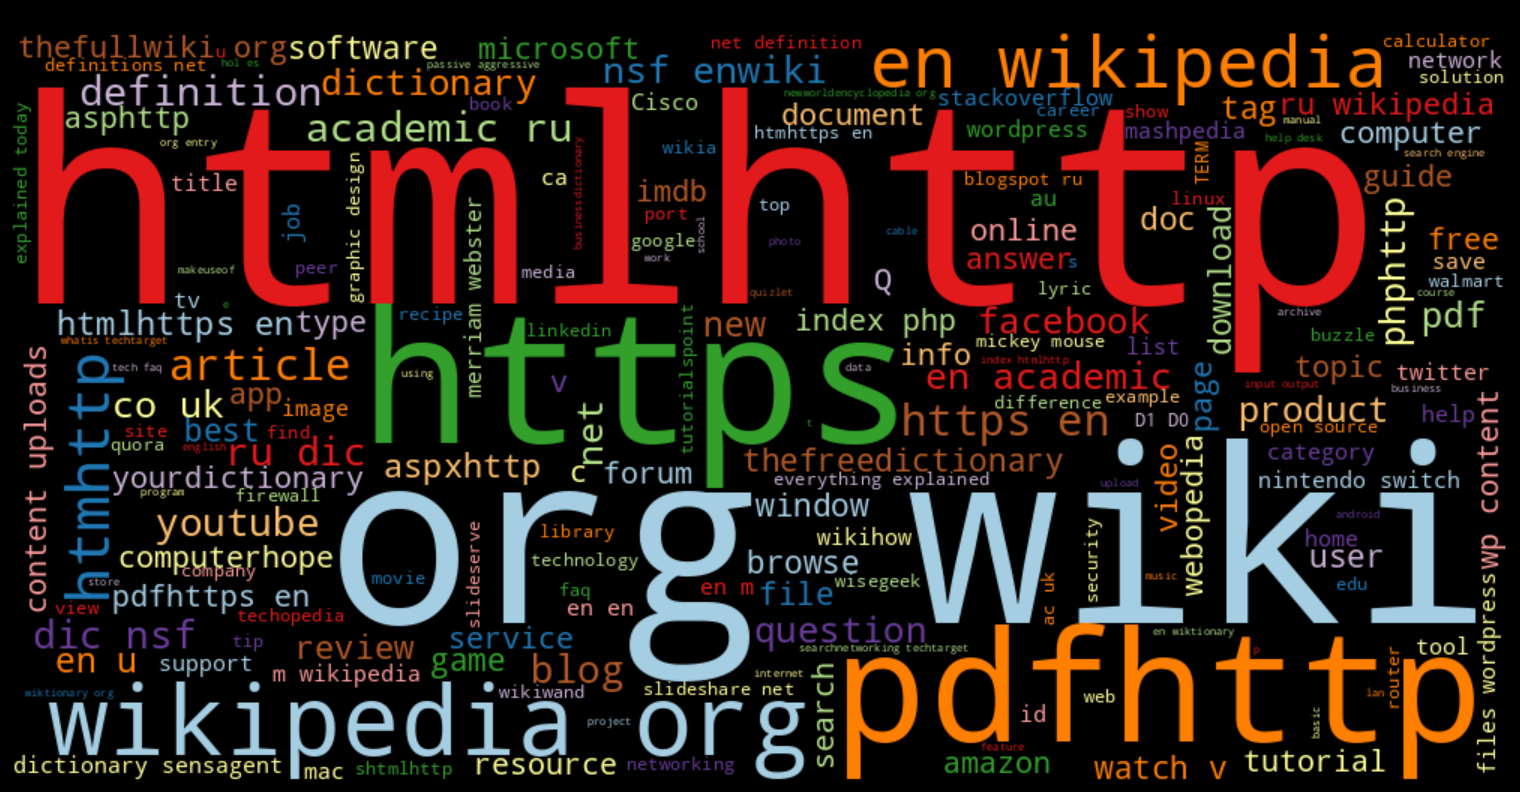

In [ ]:
#wordcloud for legitimate
benign_url=''.join(list(legitimate.url.values))
wordcloud=WordCloud(width=1000,height=500,colormap='Paired').generate(benign_url)
plt.figure(figsize=(15,15),facecolor='k')
plt.imshow(wordcloud,interpolation='bilinear')
plt.axis('off')
plt.title('legitimate URL')
plt.tight_layout(pad=0)
plt.show()

In [ ]:
##since ml model understands only numerical data we will try to extract important features from urlss to determine whether they are safe or not


In [ ]:
!pip install tldextract
# Required libraries
import pandas as pd
import numpy as np
import re
import string
import tldextract # This line will now work
from urllib.parse import urlparse
from difflib import SequenceMatcher

# Optional: Install missing packages
# !pip install tldextract

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 107.4/107.4 kB 2.7 MB/s eta 0:00:00


In [ ]:
# Sample brand names and keywords — expand this list as needed
brand_names = ["paypal", "apple", "google", "amazon", "facebook", "netflix", "microsoft", "linkedin"]
keywords = ["login", "secure", "account", "update", "verify", "signin", "password", "support"]
target_brand_names = ["paypal", "apple"]  # Adjust based on your use case
target_keywords = ["login", "verify", "account"]

# Sample English words for random word check
# For full version, use a proper dictionary like `nltk.corpus.words.words()`
english_words = set(["computer", "pencil", "notebook", "table", "login", "user", "admin", "secure"])


In [ ]:
def similar(a, b):
    return SequenceMatcher(None, a, b).ratio()

def is_random(word):
    return (
        len(word) >= 6
        and word.isalnum()
        and word.lower() not in english_words
        and not any(b in word.lower() for b in brand_names)
        and not any(k in word.lower() for k in keywords)
    )

def extract_url_features(url):
    parsed = urlparse(url)
    ext = tldextract.extract(url)

    domain = ext.domain
    subdomain = ext.subdomain
    path = parsed.path
    tld = ext.suffix

    # Split into words using special characters
    raw_words = re.split(r'[\/:\.?&=_\-@]', url)
    raw_words = [w for w in raw_words if w]

    # Word lengths
    word_lengths = [len(w) for w in raw_words]
    avg_word_len = np.mean(word_lengths) if word_lengths else 0
    longest_word_len = max(word_lengths) if word_lengths else 0
    shortest_word_len = min(word_lengths) if word_lengths else 0
    std_word_len = np.std(word_lengths) if word_lengths else 0

    # WDM module (adjacent words and decomposition) — simplified
    adjacent_words = [w for w in raw_words if len(w) > 12]
    separated_words = sum(len(re.findall(r'[a-zA-Z]{4,}', w)) for w in adjacent_words)


    # Character counts
    digit_count = sum(c.isdigit() for c in url)
    special_chars = "-./@?&=_"
    special_char_count = sum(url.count(c) for c in special_chars)


def similar(a, b):
    return SequenceMatcher(None, a, b).ratio()

def is_random(word):
    return (
        len(word) >= 6
        and word.isalnum()
        and word.lower() not in english_words
        and not any(b in word.lower() for b in brand_names)
        and not any(k in word.lower() for k in keywords)
    )

def extract_url_features(url):
    parsed = urlparse(url)
    ext = tldextract.extract(url)

    domain = ext.domain
    subdomain = ext.subdomain
    path = parsed.path
    tld = ext.suffix

    # Split into words using special characters
    raw_words = re.split(r'[\/:\.?&=_\-@]', url)
    raw_words = [w for w in raw_words if w]

    # Word lengths
    word_lengths = [len(w) for w in raw_words]
    avg_word_len = np.mean(word_lengths) if word_lengths else 0
    longest_word_len = max(word_lengths) if word_lengths else 0
    shortest_word_len = min(word_lengths) if word_lengths else 0
    std_word_len = np.std(word_lengths) if word_lengths else 0

    # WDM module (adjacent words and decomposition) — simplified
    adjacent_words = [w for w in raw_words if len(w) > 12]
    separated_words = sum(len(re.findall(r'[a-zA-Z]{4,}', w)) for w in adjacent_words)


    # Character counts
    digit_count = sum(c.isdigit() for c in url)
    special_chars = "-./@?&=_"
    special_char_count = sum(url.count(c) for c in special_chars)

    return {
        "url": url,
        "raw_word_count": len(raw_words),
        "brand_in_domain":1 if any(b in domain.lower() for b in brand_names) else 0,
        "brand_in_path":1 if any(b in path.lower() for b in brand_names) else 0,
        "avg_word_len": avg_word_len,
        "longest_word_len": longest_word_len,
        "shortest_word_len": shortest_word_len,
        "std_word_len": std_word_len,
        "adjacent_word_count": len(adjacent_words),
        "avg_adjacent_word_len": np.mean([len(w) for w in adjacent_words]) if adjacent_words else 0,
        "separated_word_count": separated_words,
        "keyword_count": sum(url.lower().count(k) for k in keywords),
        "brand_name_count": sum(url.lower().count(b) for b in brand_names),
        "similar_keyword_count": sum(similar(w.lower(), k) > 0.8 for w in raw_words for k in keywords),
        "similar_brand_name_count": sum(similar(w.lower(), b) > 0.8 for w in raw_words for b in brand_names),
        "random_word_count": sum(1 for w in raw_words if is_random(w)),
        "target_brand_name_count": sum(url.lower().count(b) for b in target_brand_names),
        "target_keyword_count": sum(url.lower().count(k) for k in target_keywords),
        "other_english_words_count": sum(1 for w in raw_words if w.lower() in english_words and w.lower() not in brand_names + keywords),
        "digit_count": digit_count,
        "subdomain_count": subdomain.count('.') + 1 if subdomain else 0,
        "random_domain": is_random(domain),
        "domain_length": len(domain),
        "subdomain_length": len(subdomain),
        "path_length": len(path),
        "known_tld":1 if tld in ["com", "org", "net", "de", "edu", "gov"] else 0,
        "has_www": 1 if  'www' in subdomain else 0,
        "has_com":1  if'com' in domain else 0,

        "uses_punycode":1 if 'xn--' in domain else 0,

        "special_char_count": special_char_count,
        "consecutive_char_repeat": bool(re.search(r'(.)\1{2,}', url)),
        "alexa_top": 0,  # Placeholder, needs external list/API
        "alexa_rank": -1,  # Placeholder
        "total_url_length": len(url),
        "path_has_keywords": int(any(k in path.lower() for k in keywords)),
        "domain_has_hyphen": 1 if '-' in domain else 0,
        "starts_with_http": 1 if  url.startswith("http") else 0,

        "contains_ip_address": 1 if  bool(re.search(r'(\d{1,3}\.){3}\d{1,3}', url)) else 0,
        "contains_port_number":1 if ':' in parsed.netloc and parsed.netloc.split(':')[-1].isdigit() else 0,
        "query_length": len(parsed.query),
        "fragment_length": len(parsed.fragment),
    }


In [ ]:
# Apply the feature extraction function to each URL
features = df['url'].apply(extract_url_features)

# Convert list of dicts to DataFrame
df_features = pd.DataFrame(features.tolist())

# Optional: merge back with original labels
df_final = pd.concat([df.label,df_features], axis=1)

# Preview
df_final.head(5)


,label,url,raw_word_count,brand_in_domain,brand_in_path,avg_word_len,longest_word_len,shortest_word_len,std_word_len,adjacent_word_count,...,alexa_top,alexa_rank,total_url_length,path_has_keywords,domain_has_hyphen,starts_with_http,contains_ip_address,contains_port_number,query_length,fragment_length
0,legitimate,http://www.bestbuy.com/site/routers/wireless-r...,12,0,0,5.833333,12,1,3.484091,0,...,0,-1,83,0,0,1,0,0,15,0
1,phishing,http://www.rooferexpert.com/css/8933617-dosar-...,15,0,0,5.666667,12,2,3.069564,0,...,0,-1,102,0,0,1,0,0,0,0
2,phishing,http://www.performanceoutdooradvertising.com/a...,9,0,0,7.777778,29,3,7.927137,1,...,0,-1,80,1,0,1,0,0,0,0
3,legitimate,https://www.androiddrawer.com/24611/download-e...,13,0,0,5.230769,13,2,2.939227,1,...,0,-1,83,0,0,1,0,0,0,0
4,legitimate,https://shippingandfreightresource.com/port-an...,9,0,0,6.333333,26,1,7.272475,1,...,0,-1,68,0,0,1,0,0,0,0


In [ ]:
#encoding
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
df_final['label_int']=le.fit_transform(df_final['label'])


In [ ]:
#deleting label column
df_final.drop(columns='label',axis=1,inplace=True)
df_final.head()

,url,raw_word_count,brand_in_domain,brand_in_path,avg_word_len,longest_word_len,shortest_word_len,std_word_len,adjacent_word_count,avg_adjacent_word_len,...,alexa_rank,total_url_length,path_has_keywords,domain_has_hyphen,starts_with_http,contains_ip_address,contains_port_number,query_length,fragment_length,label_int
0,http://www.bestbuy.com/site/routers/wireless-r...,12,0,0,5.833333,12,1,3.484091,0,0.0,...,-1,83,0,0,1,0,0,15,0,0
1,http://www.rooferexpert.com/css/8933617-dosar-...,15,0,0,5.666667,12,2,3.069564,0,0.0,...,-1,102,0,0,1,0,0,0,0,1
2,http://www.performanceoutdooradvertising.com/a...,9,0,0,7.777778,29,3,7.927137,1,29.0,...,-1,80,1,0,1,0,0,0,0,1
3,https://www.androiddrawer.com/24611/download-e...,13,0,0,5.230769,13,2,2.939227,1,13.0,...,-1,83,0,0,1,0,0,0,0,0
4,https://shippingandfreightresource.com/port-an...,9,0,0,6.333333,26,1,7.272475,1,26.0,...,-1,68,0,0,1,0,0,0,0,0


In [ ]:
x = df_final.drop(columns=['label_int', 'url'], axis=1)
y = df_final['label_int']


In [ ]:
print(x)

       raw_word_count  brand_in_domain  brand_in_path  avg_word_len  \
0                  12                0              0      5.833333   
1                  15                0              0      5.666667   
2                   9                0              0      7.777778   
3                  13                0              0      5.230769   
4                   9                0              0      6.333333   
...               ...              ...            ...           ...   
73570              15                0              0      6.733333   
73571              41                0              0      5.731707   
73572               3                0              0      4.000000   
73573               6                0              0      6.666667   
73574               7                0              0      4.857143   

       longest_word_len  shortest_word_len  std_word_len  adjacent_word_count  \
0                    12                  1      3.484091          

In [ ]:
print(y)

0        0
1        1
2        1
3        0
4        0
        ..
73570    1
73571    1
73572    0
73573    1
73574    1
Name: label_int, Length: 73575, dtype: int64


In [ ]:
#splitting the data into trin and test data
#since in y all the two cases have differnt no. of values so we startify it so that our model learn from equal no. of data points
x_train,x_test,y_train,y_test=train_test_split(x,y,stratify=y,test_size=0.2,random_state=42)


In [ ]:
#model training
#1.logistic regression
from sklearn.linear_model import LogisticRegression
lr=LogisticRegression()
#fitting the training data into the model
lr.fit(x_train,y_train)
#model evaulation (logistic-train)
train_data_prediction=lr.predict(x_train)
train_data_accuracy=accuracy_score(y_train,train_data_prediction)
print("The accuracy on training data is:",train_data_accuracy)
#model evaulation (logistic-test)
test_data_prediction=lr.predict(x_test)
test_data_accuracy=accuracy_score(y_test,test_data_prediction)
print("The accuracy on testing data is:",test_data_accuracy)
print(classification_report(y_test,test_data_prediction,target_names=['phising','legitimate']))


The accuracy on training data is: 0.8043493034318723
The accuracy on testing data is: 0.8040095141012572
              precision    recall  f1-score   support

     phising       0.79      0.83      0.81      7280
  legitimate       0.82      0.78      0.80      7435

    accuracy                           0.80     14715
   macro avg       0.80      0.80      0.80     14715
weighted avg       0.81      0.80      0.80     14715



/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
# KNN model training
from sklearn.neighbors import KNeighborsClassifier
knn=KNeighborsClassifier()
#fitting the training data into the model
knn.fit(x_train,y_train)
#model evaulation (knn-train)
train_data_prediction=knn.predict(x_train)
train_data_accuracy=accuracy_score(y_train,train_data_prediction)
print("The accuracy on training data is:",train_data_accuracy)
# model evaluation(knn-test)
test_data_prediction=knn.predict(x_test)
test_data_accuracy=accuracy_score(y_test,test_data_prediction)
print("The accuracy on testing data is:",test_data_accuracy)
print(classification_report(y_test,test_data_prediction,target_names=['phishing','legitimate']))

The accuracy on training data is: 0.9043832823649337
The accuracy on testing data is: 0.8581039755351682
              precision    recall  f1-score   support

    phishing       0.85      0.86      0.86      7280
  legitimate       0.86      0.85      0.86      7435

    accuracy                           0.86     14715
   macro avg       0.86      0.86      0.86     14715
weighted avg       0.86      0.86      0.86     14715



In [ ]:
#Decision tree model training
from sklearn.tree import DecisionTreeClassifier
dt=DecisionTreeClassifier()
#fitting the training data into the model
dt.fit(x_train,y_train)
#model evaulation (dt-train)
train_data_prediction=dt.predict(x_train)
train_data_accuracy=accuracy_score(y_train,train_data_prediction)
print("The accuracy on training data is:",train_data_accuracy)
#model evaulation (dt-test)
test_data_prediction=dt.predict(x_test)
test_data_accuracy=accuracy_score(y_test,test_data_prediction)
print("The accuracy on testing data is:",test_data_accuracy)
print(classification_report(y_test,test_data_prediction,target_names=['phishing','legitimate']))

The accuracy on training data is: 0.9942575603126061
The accuracy on testing data is: 0.9030241250424736
              precision    recall  f1-score   support

    phishing       0.91      0.89      0.90      7280
  legitimate       0.89      0.92      0.91      7435

    accuracy                           0.90     14715
   macro avg       0.90      0.90      0.90     14715
weighted avg       0.90      0.90      0.90     14715



In [ ]:
#Naive bayes
from sklearn.naive_bayes import GaussianNB
nb=GaussianNB()
#fitting the training data into the model
nb.fit(x_train,y_train)
#model evaulation (nb-train)
train_data_prediction=nb.predict(x_train)
train_data_accuracy=accuracy_score(y_train,train_data_prediction)
print("The accuracy on training data is:",train_data_accuracy)
# model evalaution (nb-test)
test_data_prediction=nb.predict(x_test)
test_data_accuracy=accuracy_score(y_test,test_data_prediction)
print("The accuracy on testing data is:",test_data_accuracy)
print(classification_report(y_test,test_data_prediction,target_names=['phishing','legitimate']))

The accuracy on training data is: 0.6593102276588515
The accuracy on testing data is: 0.655113829425756
              precision    recall  f1-score   support

    phishing       0.59      0.95      0.73      7280
  legitimate       0.88      0.37      0.52      7435

    accuracy                           0.66     14715
   macro avg       0.74      0.66      0.62     14715
weighted avg       0.74      0.66      0.62     14715



In [ ]:
#random forest model training
from sklearn.ensemble import RandomForestClassifier
rf=RandomForestClassifier() # Instantiate the class
rf.fit(x_train,y_train)
#model evaluation-rf train
train_data_prediction=rf.predict(x_train)
train_data_accuracy=accuracy_score(y_train,train_data_prediction)
print("The accuracy on training data is:",train_data_accuracy)
#model evaluation-rf test
test_data_prediction=rf.predict(x_test)
test_data_accuracy=accuracy_score(y_test,test_data_prediction)
print("The accuracy on testing data is:",test_data_accuracy)
print(classification_report(y_test,test_data_prediction,target_names=['phishing','legitimate']))

The accuracy on training data is: 0.9942575603126061
The accuracy on testing data is: 0.927896704043493
              precision    recall  f1-score   support

    phishing       0.94      0.91      0.93      7280
  legitimate       0.91      0.95      0.93      7435

    accuracy                           0.93     14715
   macro avg       0.93      0.93      0.93     14715
weighted avg       0.93      0.93      0.93     14715



In [ ]:
#xgboost
#xgboost classifier-model training
!pip install xgboost
from xgboost import XGBClassifier  # Import XGBClassifier instead of XGBRegressor
xgb = XGBClassifier() # Instantiate XGBClassifier
xgb.fit(x_train,y_train)
#model evaulation (xgb-train)
train_data_prediction=xgb.predict(x_train)
train_data_accuracy=accuracy_score(y_train,train_data_prediction)
print("The accuracy on training data is:",train_data_accuracy)
#model evaluation(xgb-test)
test_data_prediction=xgb.predict(x_test)
test_data_accuracy=accuracy_score(y_test,test_data_prediction)
print("The accuracy on testing data is:",test_data_accuracy)
# Ensure target_names match the order of the integer labels (0, 1, 2, 3)
print(classification_report(y_test,test_data_prediction,target_names=['phishing','legitimate']))

The accuracy on training data is: 0.9195548759768943
The accuracy on testing data is: 0.8984029901461094
              precision    recall  f1-score   support

    phishing       0.90      0.90      0.90      7280
  legitimate       0.90      0.90      0.90      7435

    accuracy                           0.90     14715
   macro avg       0.90      0.90      0.90     14715
weighted avg       0.90      0.90      0.90     14715



In [ ]:
#adaboost classifier
from sklearn.ensemble import AdaBoostClassifier
ada=AdaBoostClassifier()
ada.fit(x_train,y_train)
#model evaulation (ada-train)
train_data_prediction=ada.predict(x_train)
train_data_accuracy=accuracy_score(y_train,train_data_prediction)
print("The accuracy on training data is:",train_data_accuracy)
#model evaulation (ada-test)
test_data_prediction=ada.predict(x_test)
test_data_accuracy=accuracy_score(y_test,test_data_prediction)
print("The accuracy on testing data is:",test_data_accuracy)
print(classification_report(y_test,test_data_prediction,target_names=['phishing','legitimate']))

The accuracy on training data is: 0.8154604145429833
The accuracy on testing data is: 0.818008834522596
              precision    recall  f1-score   support

    phishing       0.79      0.85      0.82      7280
  legitimate       0.84      0.78      0.81      7435

    accuracy                           0.82     14715
   macro avg       0.82      0.82      0.82     14715
weighted avg       0.82      0.82      0.82     14715



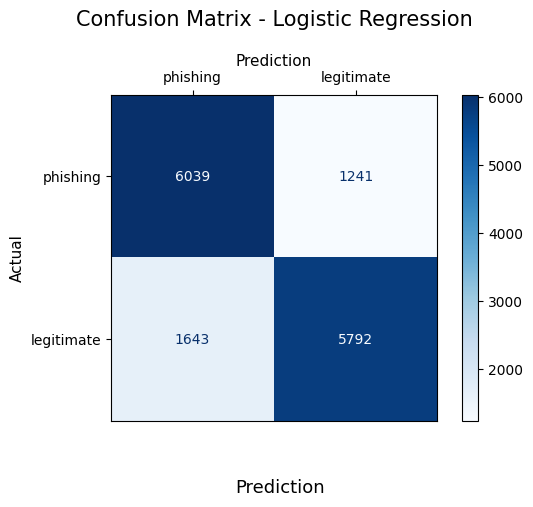

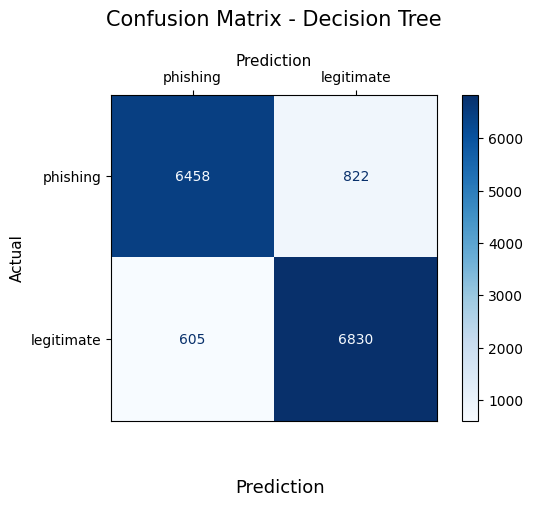

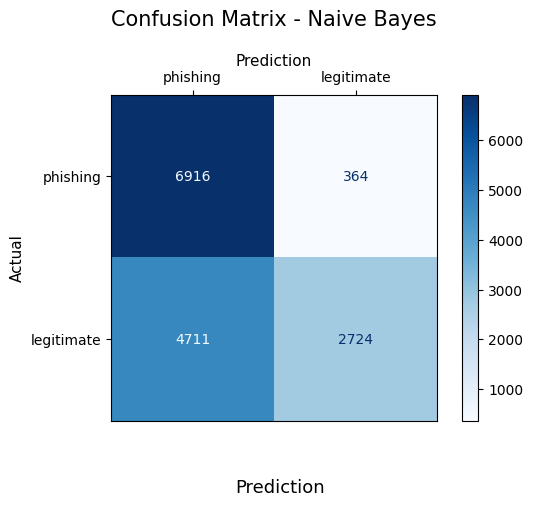

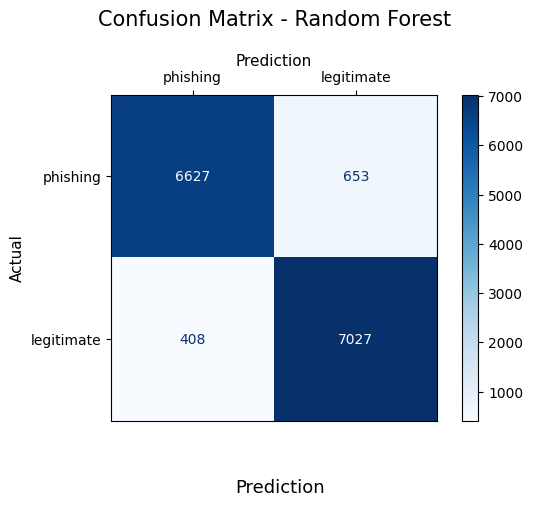

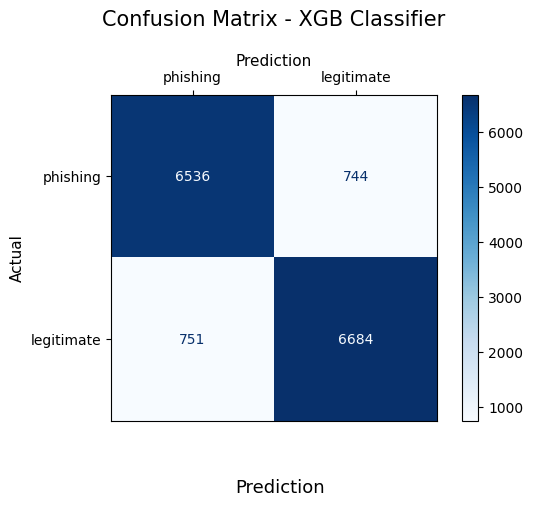

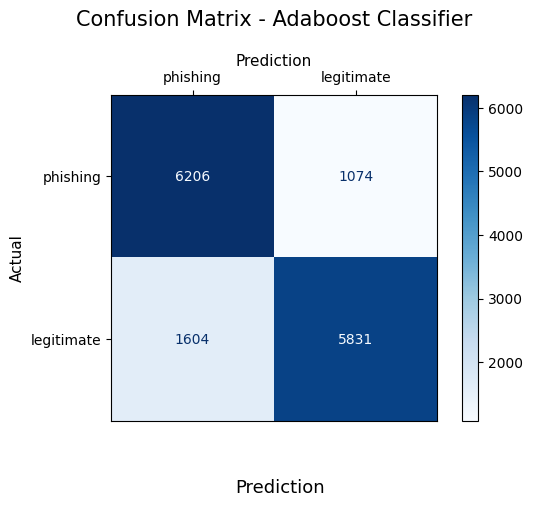

In [ ]:
#confustion matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np # Import numpy

models = [lr, dt, nb, rf,xgb,ada]
model_names = ['Logistic Regression','Decision Tree', 'Naive Bayes', 'Random Forest','XGB Classifier','Adaboost Classifier']
# Original class names for display purposes
class_names = ['phishing','legitimate']
# The actual labels in y_test are integers (0, 1, 2, 3)
# We need to pass these integer labels to confusion_matrix
actual_labels_in_ytest = np.unique(y_test) # Get the unique integer labels from y_test

for model, name in zip(models, model_names):
    test_data_prediction = model.predict(x_test)
    # Pass the actual integer labels from y_test to confusion_matrix
    # Use display_labels to map the integer labels to the string class names for the plot
    cm = confusion_matrix(y_test, test_data_prediction, labels=actual_labels_in_ytest)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)

    disp.plot(cmap=plt.cm.Blues)
    plt.title(f'Confusion Matrix - {name}', fontsize=15, pad=20)
    plt.xlabel('Prediction', fontsize=11)
    plt.ylabel('Actual', fontsize=11)
    plt.gca().xaxis.set_label_position('top')
    plt.gca().xaxis.tick_top()
    plt.gca().figure.subplots_adjust(bottom=0.2)
    plt.gca().figure.text(0.5, 0.05, 'Prediction', ha='center', fontsize=13)

    plt.show()

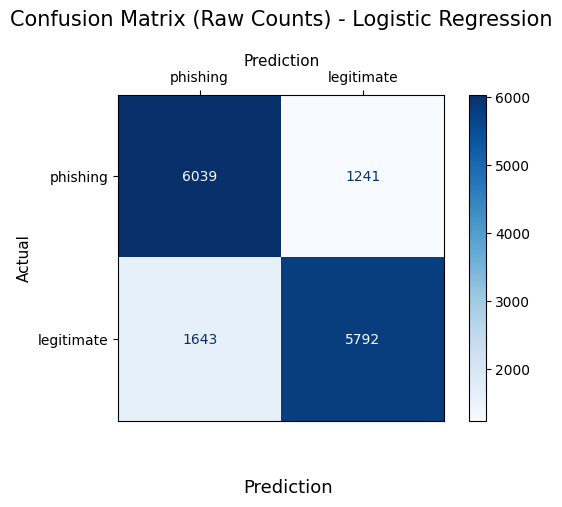

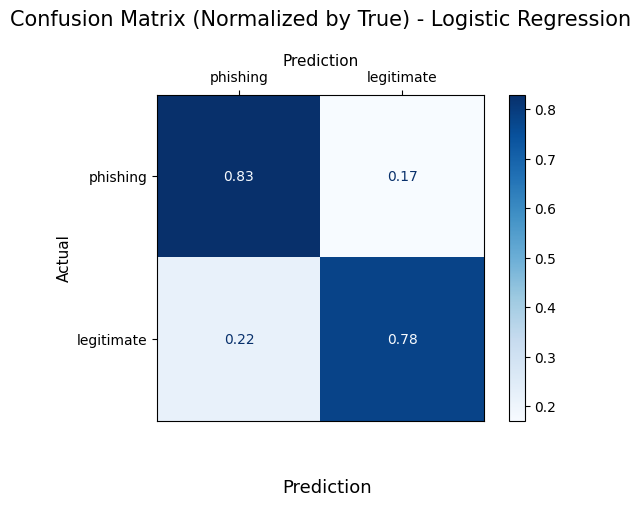

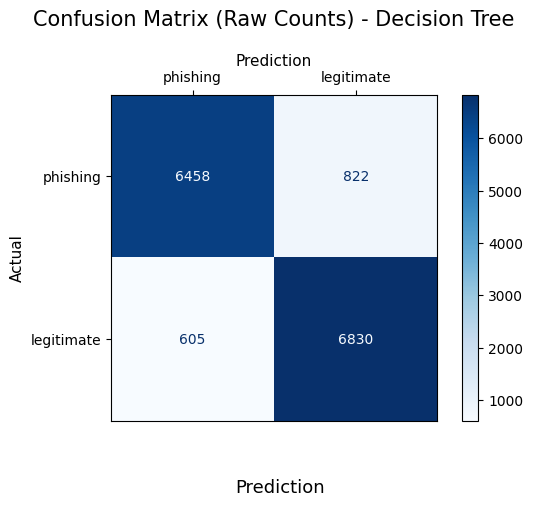

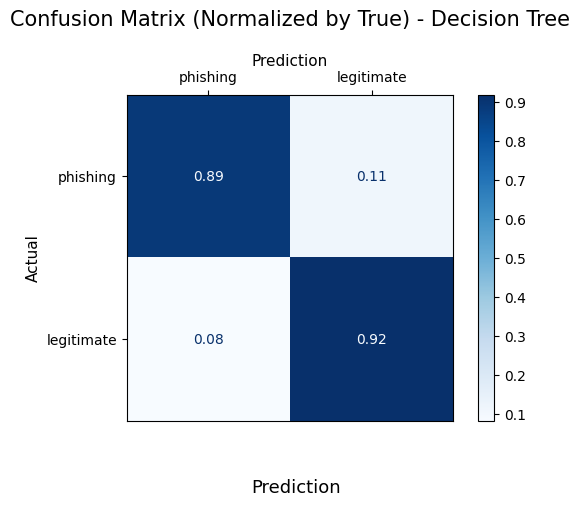

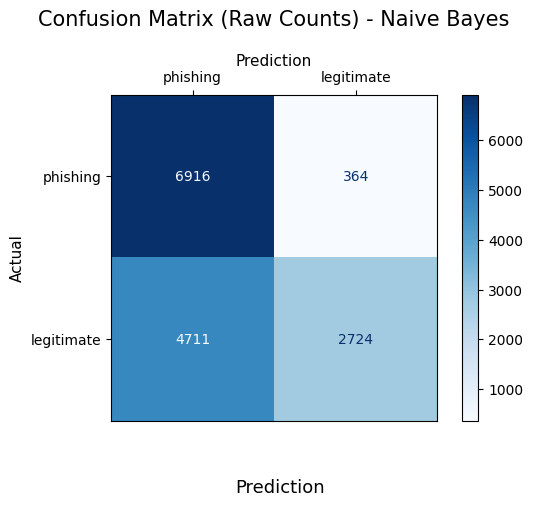

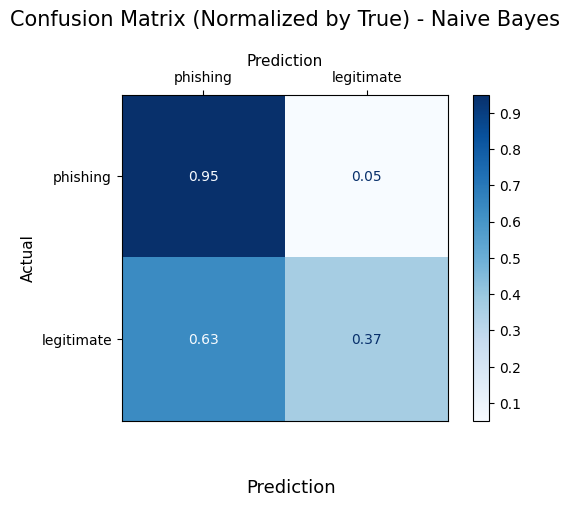

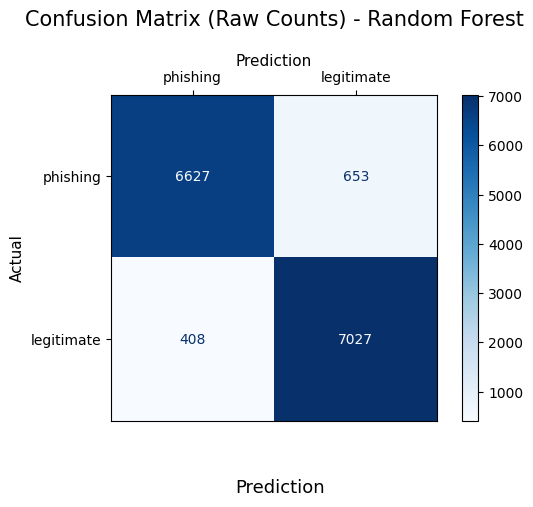

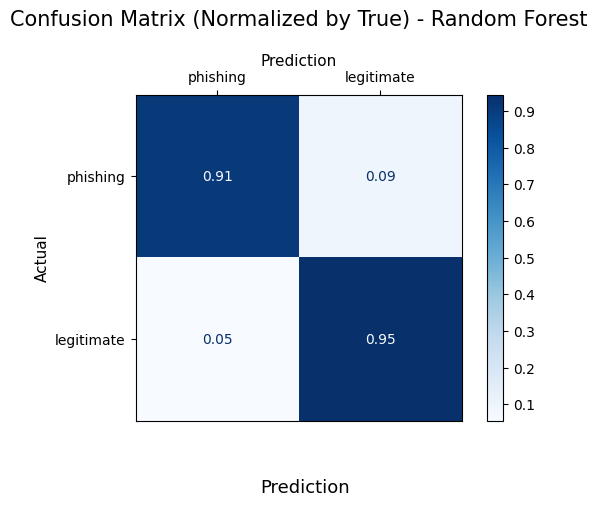

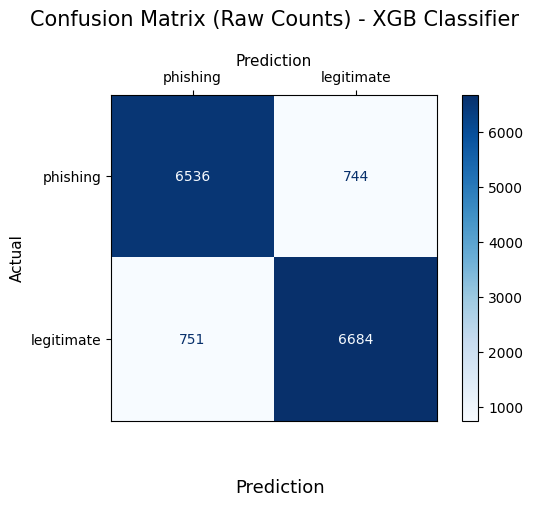

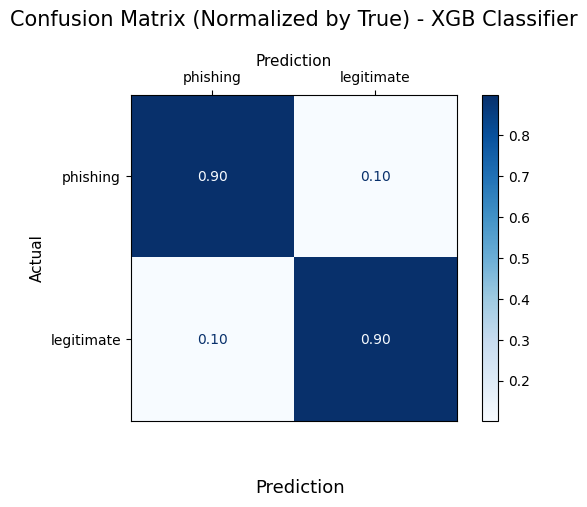

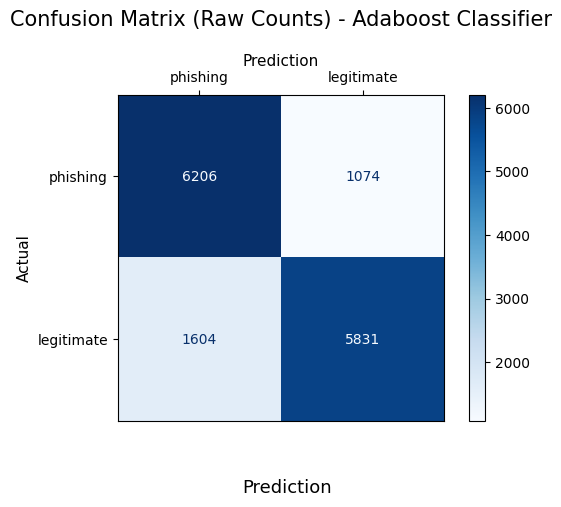

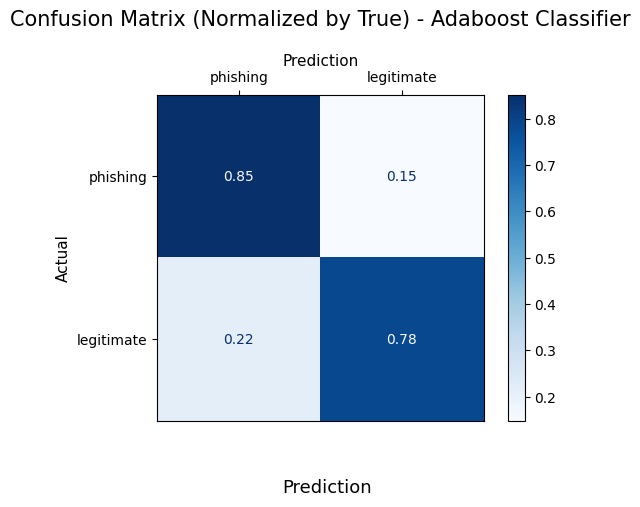

In [ ]:
#weighted confusion matrix
#weighted confusion matrix

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np # Import numpy

models = [lr, dt, nb, rf,xgb,ada]
model_names = ['Logistic Regression','Decision Tree', 'Naive Bayes', 'Random Forest','XGB Classifier','Adaboost Classifier']
# Original class names for display purposes
class_names = ['phishing','legitimate']
# The actual labels in y_test are integers (0, 1, 2)
# We need to pass these integer labels to confusion_matrix
actual_labels_in_ytest = np.unique(y_test) # Get the unique integer labels from y_test

for model, name in zip(models, model_names):
    test_data_prediction = model.predict(x_test)
    # Pass the actual integer labels from y_test to confusion_matrix

    # Calculate the confusion matrix (raw counts)
    cm = confusion_matrix(y_test, test_data_prediction, labels=actual_labels_in_ytest)

    # Calculate the normalized confusion matrix (normalized by rows - 'true' labels)
    # This shows the proportion of predictions for each actual class
    cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    # Display the RAW confusion matrix
    disp_raw = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp_raw.plot(cmap='Blues', values_format='d') # Use 'd' to format as integers
    plt.title(f'Confusion Matrix (Raw Counts) - {name}', fontsize=15, pad=20)
    plt.xlabel('Prediction', fontsize=11)
    plt.ylabel('Actual', fontsize=11)
    plt.gca().xaxis.set_label_position('top')
    plt.gca().xaxis.tick_top()
    plt.gca().figure.subplots_adjust(bottom=0.2)
    plt.gca().figure.text(0.5, 0.05, 'Prediction', ha='center', fontsize=13)
    plt.show()

    # Display the NORMALIZED confusion matrix
    disp_norm = ConfusionMatrixDisplay(confusion_matrix=cm_normalized, display_labels=class_names)
    # Use '.2f' to format as floats with 2 decimal places
    disp_norm.plot(cmap='Blues', values_format='.2f')
    plt.title(f'Confusion Matrix (Normalized by True) - {name}', fontsize=15, pad=20)
    plt.xlabel('Prediction', fontsize=11)
    plt.ylabel('Actual', fontsize=11)
    plt.gca().xaxis.set_label_position('top')
    plt.gca().xaxis.tick_top()
    plt.gca().figure.subplots_adjust(bottom=0.2)
    plt.gca().figure.text(0.5, 0.05, 'Prediction', ha='center', fontsize=13)
    plt.show()

# %%
#feature impotance


Expected: 2, Got: 1
Expected: 1, Got: 2


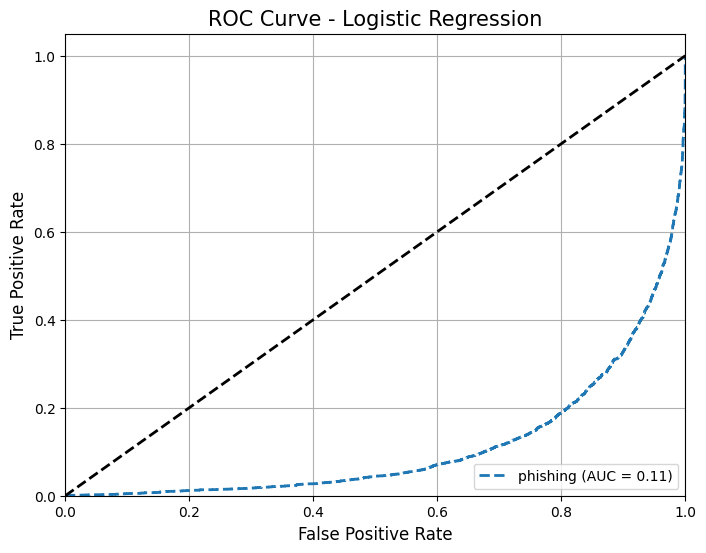

Expected: 1, Got: 2


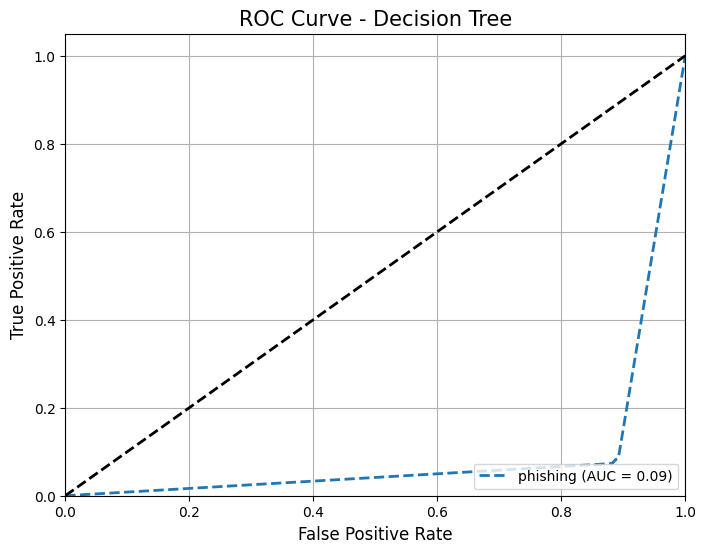

Expected: 1, Got: 2


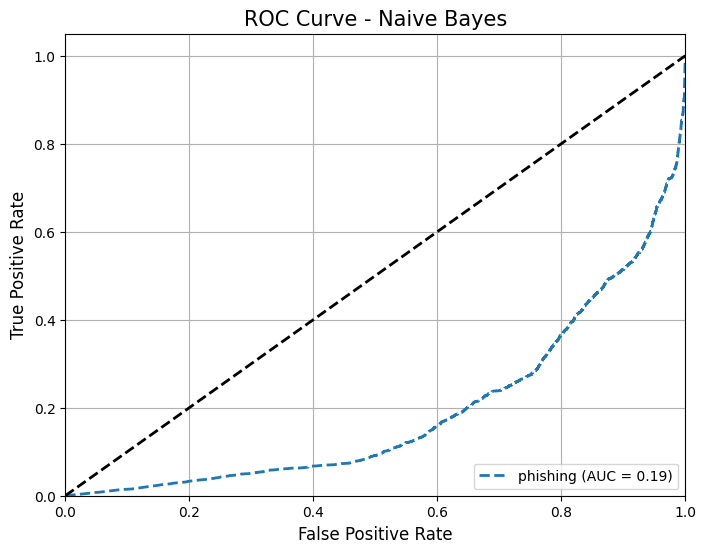

Expected: 1, Got: 2


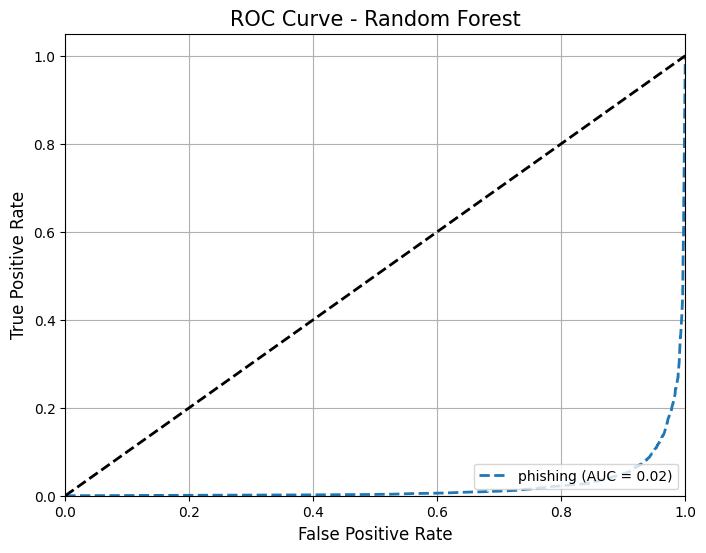

Expected: 1, Got: 2


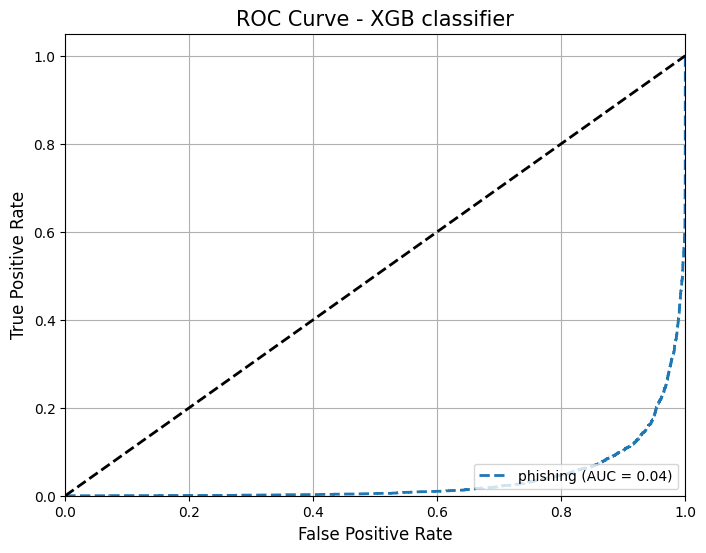

Expected: 1, Got: 2


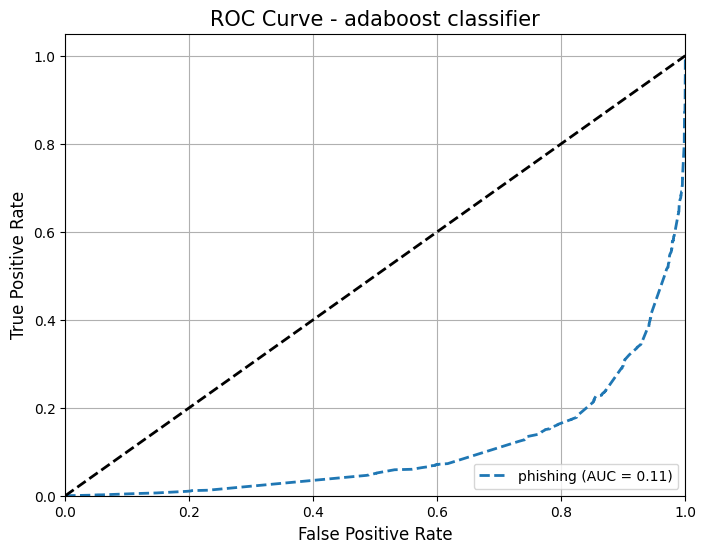

In [ ]:
#auc-roc curve for the above models
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
from sklearn.multiclass import OneVsRestClassifier
import numpy as np

models = [lr, dt, nb, rf,xgb,ada]
model_names = ['Logistic Regression', 'Decision Tree', 'Naive Bayes', 'Random Forest','XGB classifier','adaboost classifier']
# Get the unique integer labels from y_test for binarization
actual_integer_classes = np.unique(y_test)
# Define class names for display purposes, corresponding to the integer labels
display_class_names = ['phishing','legitimate']

# Binarize the output labels using the actual integer classes
# Pass the actual integer classes found in y_test to label_binarize
y_test_bin = label_binarize(y_test, classes=actual_integer_classes)

# Check the shape of y_test_bin to ensure it has n_classes columns
if y_test_bin.shape[1] != len(actual_integer_classes):
    print("Warning: label_binarize did not produce the expected number of columns.")
    print(f"Expected: {len(actual_integer_classes)}, Got: {y_test_bin.shape[1]}")
    # Handle the error, perhaps by inspecting y_test and actual_integer_classes
    # For this specific case with 2 classes, this check is less critical
    # but useful for multi-class problems.

# Update n_classes based on the binarized output shape
n_classes = y_test_bin.shape[1]

for model, name in zip(models, model_names):
    # Predict probabilities
    y_score = model.predict_proba(x_test)

    # Check that y_score has the same number of columns as y_test_bin
    if y_score.shape[1] != n_classes:
         print(f"Warning: Model {name} predict_proba output shape mismatch.")
         print(f"Expected: {n_classes}, Got: {y_score.shape[1]}")
         # This might happen if a model only predicts one class (e.g., due to data imbalance)
         # For now, we'll proceed but this is a potential issue point.
         # For binary classification, y_score should have 2 columns.
         # If it has only 1, roc_curve(..., y_score[:, i]) will fail for i=1.
         # We need to ensure the model predicts probabilities for both classes.

    #roc curve for classes
    fpr={}
    tpr={}
    thresh={}
    roc_auc={}

    # Iterate through the actual integer classes present in the data
    # Use the index 'i' which corresponds to the column in y_test_bin and y_score
    for i in range(n_classes):
        # Ensure the current class index 'i' is within the bounds of y_test_bin and y_score
        if i < y_test_bin.shape[1] and i < y_score.shape[1]:
             # Calculate ROC curve for each class
             fpr[i], tpr[i], thresh[i] = roc_curve(y_test_bin[:, i], y_score[:, i])
             roc_auc[i] = auc(fpr[i], tpr[i])
        else:
             print(f"Skipping ROC calculation for class index {i} due to shape mismatch.")
             continue # Skip to the next iteration if index is out of bounds

    # Plot settings
    plt.figure(figsize=(8, 6))

    # Plot ROC curve for each class that was successfully calculated
    for i in roc_auc: # Iterate through the indices that have ROC data
        # Use display_class_names to get the string name for the class
        # Ensure the index 'i' is valid for display_class_names
        if i < len(display_class_names):
            plt.plot(fpr[i], tpr[i], linestyle='--', lw=2, label=f'{display_class_names[i]} (AUC = {roc_auc[i]:.2f})')
        else:
             print(f"Warning: Could not find display name for class index {i}.")
             plt.plot(fpr[i], tpr[i], linestyle='--', lw=2, label=f'Class {i} (AUC = {roc_auc[i]:.2f})')


    plt.plot([0, 1], [0, 1], 'k--', lw=2)
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate', fontsize=12)
    plt.ylabel('True Positive Rate', fontsize=12)
    plt.title(f'ROC Curve - {name}', fontsize=15)
    plt.legend(loc='lower right')
    plt.grid(True)
    plt.show()